In [1]:
# ============================================================
# STEP 1 — Environment Setup & Data Loading
# AI Boom vs Data Center Sustainability
# ============================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
from pathlib import Path
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

pio.renderers.default = "notebook"

print("✅ All imports successful — ready to build")

✅ All imports successful — ready to build


Both data files found successfully.
Loading File 1: AI_DataCenter_Sustainability_Datasets.xlsx ...
  ✅ File 1 loaded — 10 sheets

Loading File 2: AI_Boom_vs_DC_Sustainability_FINAL.xlsx ...
  ✅ File 2 loaded — 9 sheets

✅ Column names cleaned.

✅ Historical rows (core time series): 10
   Projected rows (core time series):  5

DATA AUDIT REPORT

📊 df_core_ts  (File 2, Sh.2 — Primary ML Feature Table)
   Shape: 17 rows × 13 columns
   Missing values in 13 columns:
     → Year: 1 missing (5.9%)
     → Global DC Energy (TWh): 2 missing (11.8%)
     → AI Share of DC Energy (%): 2 missing (11.8%)
     → Hyperscaler Electricity (TWh): 2 missing (11.8%)
     → Global AI Private Inv. ($B): 8 missing (47.1%)
     → GenAI Investment ($B): 2 missing (11.8%)
     → GPU/AI Chip Revenue ($B): 6 missing (35.3%)
     → GPU Shipments for AI (M units): 6 missing (35.3%)
     → Hyperscale DC Count: 2 missing (11.8%)
     → DC Carbon Emissions (MtCO2e): 2 missing (11.8%)
     → Renewable % of DC Electricit

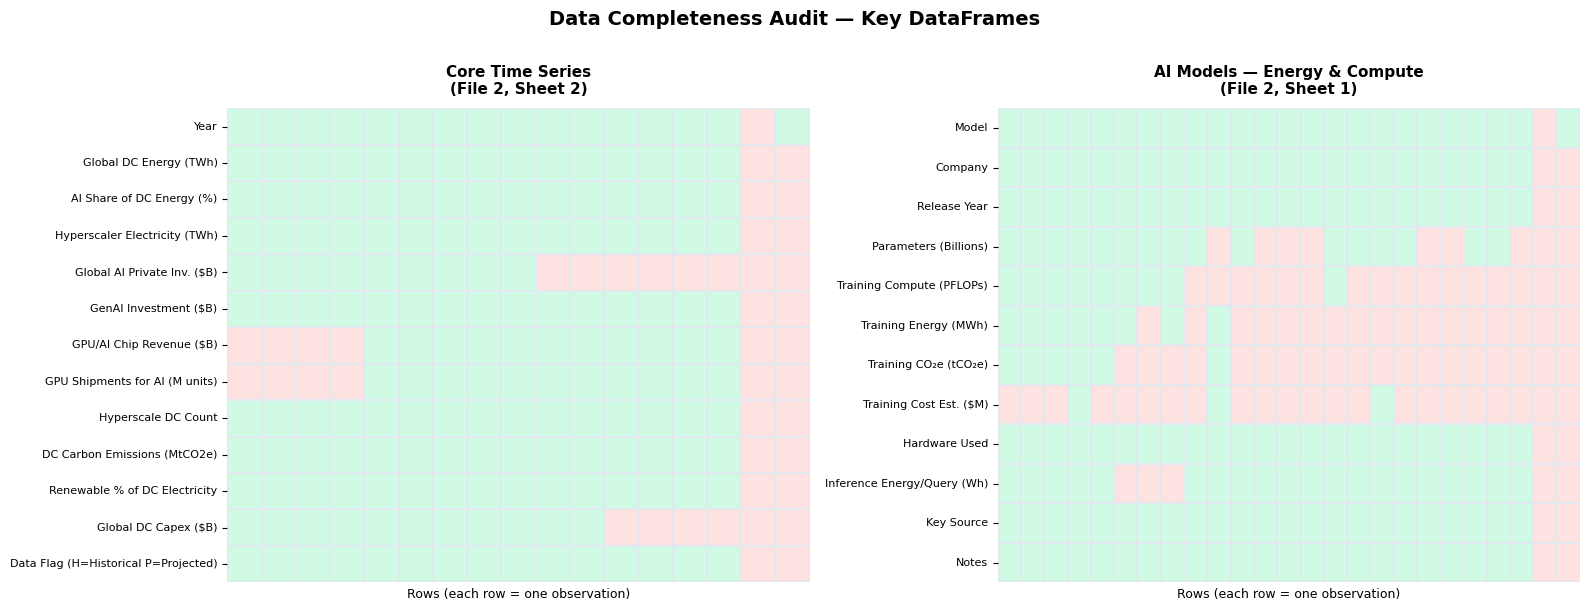


✅ Audit chart saved → outputs/charts/01_data_completeness_audit.png
✅ Data dictionary saved → outputs/charts/01_data_dictionary.csv

✅ STEP 1 COMPLETE

All DataFrames are loaded and ready for analysis.

Key objects available for import into later notebooks:
  df_core_hist     → historical ML training data (core time series)
  df_core_proj     → projected data (for forecast validation)
  df_ai_models     → AI model compute & energy data
  df_hyperscalers  → per-company sustainability (Google/MSFT/Amazon/Meta)
  df_inference     → inference energy at scale
  df_grid_carbon   → regional grid carbon intensity
  df_capex_gap     → sustainability pledge vs actual gap
  df_scenarios     → forward scenarios to 2035

Next: Run 02_eda.py for Exploratory Data Analysis.



In [4]:
# ── 0. Path configuration ────────────────────────────────────────────────────
# All paths are relative to the project root.
# Run this script from ai_sustainability_project/ in your terminal.

ROOT = Path(r'C:\Users\sayan\Desktop\Data_Analysis\ai_sustainability_project')
DATA_DIR = ROOT / 'data'
OUT_DIR = ROOT / 'outputs' / 'charts'
MDL_DIR = ROOT / 'outputs' / 'models'

OUT_DIR.mkdir(parents=True, exist_ok=True)
MDL_DIR.mkdir(parents=True, exist_ok=True)

FILE1 = DATA_DIR / 'AI_DataCenter_Sustainability_Datasets.xlsx'
FILE2 = DATA_DIR / 'AI_Boom_vs_DC_Sustainability_FINAL.xlsx'

#Confirm files exist
for f in [FILE1, FILE2]:
    assert f.exists(), f"File not found: {f}"
print('Both data files found successfully.')

# ── 1. Load File 1 — Macro Context ───────────────────────────────────────────
# File 1 is the big-picture dataset: global totals, regional breakdowns,
# long-run trends. We use it for context-setting and Act I narrative charts.

print("Loading File 1: AI_DataCenter_Sustainability_Datasets.xlsx ...")

f1_sheets = pd.read_excel(FILE1, sheet_name=None, header=None)

# Each sheet has a 2-row title block before the actual headers.
# Row index 3 (0-based) is always the column header row in our workbook.
# We reload each sheet specifying header=3 to skip the title rows.

df_dc_global      = pd.read_excel(FILE1, sheet_name=1, header=3)   # Global DC energy by region
df_dc_by_type     = pd.read_excel(FILE1, sheet_name=2, header=3)   # Energy by equipment type
df_pue_wue        = pd.read_excel(FILE1, sheet_name=3, header=3)   # PUE / WUE efficiency
df_dc_carbon      = pd.read_excel(FILE1, sheet_name=4, header=3)   # Carbon emissions
df_ai_market      = pd.read_excel(FILE1, sheet_name=5, header=3)   # AI market size
df_ai_adoption    = pd.read_excel(FILE1, sheet_name=6, header=3)   # AI adoption & compute
df_cloud_infra    = pd.read_excel(FILE1, sheet_name=7, header=3)   # Cloud infrastructure
df_hyperscale_f1  = pd.read_excel(FILE1, sheet_name=8, header=3)   # Hyperscale DC growth
df_dc_investment  = pd.read_excel(FILE1, sheet_name=9, header=3)   # DC investment
df_projections_f1 = pd.read_excel(FILE1, sheet_name=10, header=3)  # Forward projections

print("  ✅ File 1 loaded — 10 sheets\n")

# ── 2. Load File 2 — Analysis Engine ─────────────────────────────────────────
# File 2 is the granular, ML-ready dataset. This is where the actual
# modelling work happens. Each sheet is purpose-built for a specific
# analysis task.

print("Loading File 2: AI_Boom_vs_DC_Sustainability_FINAL.xlsx ...")

df_ai_models      = pd.read_excel(FILE2, sheet_name=1, header=3)   # AI models energy & compute
df_core_ts        = pd.read_excel(FILE2, sheet_name=2, header=3)   # Core time series (ML features)
df_hyperscalers   = pd.read_excel(FILE2, sheet_name=3, header=3)   # Hyperscaler sustainability
df_ai_kpis        = pd.read_excel(FILE2, sheet_name=4, header=3)   # AI boom KPIs
df_dc_sust        = pd.read_excel(FILE2, sheet_name=5, header=3)   # DC sustainability metrics
df_inference      = pd.read_excel(FILE2, sheet_name=6, header=3)   # Inference at scale
df_grid_carbon    = pd.read_excel(FILE2, sheet_name=7, header=3)   # Regional grid carbon
df_capex_gap      = pd.read_excel(FILE2, sheet_name=8, header=3)   # Capex vs sustainability gap
df_scenarios      = pd.read_excel(FILE2, sheet_name=9, header=3)   # Forward scenarios

print("  ✅ File 2 loaded — 9 sheets\n")


# ── 3. Clean column names ─────────────────────────────────────────────────────
# Excel column headers have newlines (\n) from multi-line header cells.
# We strip them to single-line names for clean DataFrame access.

def clean_columns(df):
    df.columns = (
        df.columns
        .astype(str)
        .str.replace(r'\n', ' ', regex=True)
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )
    # Drop completely empty columns (openpyxl sometimes reads trailing empties)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
    return df

all_dfs = {
    # File 1
    'dc_global':      df_dc_global,
    'dc_by_type':     df_dc_by_type,
    'pue_wue':        df_pue_wue,
    'dc_carbon':      df_dc_carbon,
    'ai_market':      df_ai_market,
    'ai_adoption':    df_ai_adoption,
    'cloud_infra':    df_cloud_infra,
    'hyperscale_f1':  df_hyperscale_f1,
    'dc_investment':  df_dc_investment,
    'projections_f1': df_projections_f1,
    # File 2
    'ai_models':      df_ai_models,
    'core_ts':        df_core_ts,
    'hyperscalers':   df_hyperscalers,
    'ai_kpis':        df_ai_kpis,
    'dc_sust':        df_dc_sust,
    'inference':      df_inference,
    'grid_carbon':    df_grid_carbon,
    'capex_gap':      df_capex_gap,
    'scenarios':      df_scenarios,
}

for name, df in all_dfs.items():
    all_dfs[name] = clean_columns(df)

# Re-assign cleaned versions
(df_dc_global, df_dc_by_type, df_pue_wue, df_dc_carbon, df_ai_market,
 df_ai_adoption, df_cloud_infra, df_hyperscale_f1, df_dc_investment,
 df_projections_f1, df_ai_models, df_core_ts, df_hyperscalers, df_ai_kpis,
 df_dc_sust, df_inference, df_grid_carbon, df_capex_gap, df_scenarios) = all_dfs.values()

print("✅ Column names cleaned.\n")


# ── 4. Separate historical from projected data ────────────────────────────────
# The core time series (df_core_ts) and scenarios sheet have a 'Data Flag'
# column: H = Historical (use for ML training), P = Projected (use for
# validation and scenario planning only — NEVER train on projected data).

# Core time series split
df_core_hist = df_core_ts[df_core_ts.iloc[:, -1].astype(str).str.strip() == 'H'].copy()
df_core_proj = df_core_ts[df_core_ts.iloc[:, -1].astype(str).str.strip() == 'P'].copy()

# AI KPIs split
df_kpis_hist = df_ai_kpis[df_ai_kpis.iloc[:, -1].astype(str).str.strip() == 'H'].copy()

print(f"✅ Historical rows (core time series): {len(df_core_hist)}")
print(f"   Projected rows (core time series):  {len(df_core_proj)}\n")


# ── 5. Data Audit ─────────────────────────────────────────────────────────────
# A structured audit of every key DataFrame. We check:
#   (a) Shape — how many rows and columns
#   (b) Missing values — count and % per column
#   (c) Data types — numeric where expected?
# The audit output is your data dictionary starting point.

print("=" * 65)
print("DATA AUDIT REPORT")
print("=" * 65)

def audit_df(name, df, key_cols=None):
    print(f"\n📊 {name}")
    print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")

    # Missing value summary
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(1)
    missing_df = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
    missing_df = missing_df[missing_df['Missing'] > 0]

    if missing_df.empty:
        print("   Missing values: None ✅")
    else:
        print(f"   Missing values in {len(missing_df)} columns:")
        for col, row in missing_df.iterrows():
            print(f"     → {col}: {int(row['Missing'])} missing ({row['Missing %']}%)")

    # Key columns preview
    if key_cols:
        available = [c for c in key_cols if c in df.columns]
        if available:
            print(f"   Key columns available: {available}")

audit_df("df_core_ts  (File 2, Sh.2 — Primary ML Feature Table)",
         df_core_ts,
         key_cols=['Year', 'Global DC Energy (TWh)', 'AI Share of DC Energy (%)',
                   'Global AI Private Inv. ($B)', 'GPU/AI Chip Revenue ($B)'])

audit_df("df_ai_models  (File 2, Sh.1 — AI Models Energy)",
         df_ai_models,
         key_cols=['Model', 'Parameters (Billions)', 'Training Energy (MWh)',
                   'Training CO₂e (tCO₂e)', 'Inference Energy/Query (Wh)'])

audit_df("df_hyperscalers  (File 2, Sh.3 — Hyperscaler Sustainability)",
         df_hyperscalers,
         key_cols=['Company', 'Year', 'Total Electricity (TWh)',
                   'Total GHG (Mt CO₂e)', 'Renewable Energy (%)'])

audit_df("df_dc_sust  (File 2, Sh.5 — DC Sustainability Metrics)",
         df_dc_sust,
         key_cols=['Year', 'Global Avg PUE', 'Global Avg WUE (L/kWh)',
                   'Renewable % of DC Electricity'])

audit_df("df_capex_gap  (File 2, Sh.8 — Capex vs Sustainability Gap)",
         df_capex_gap,
         key_cols=['Company', 'Year', 'DC Capex ($B)',
                   'Gap (Pledge-Actual %)', 'Sustainability Score (1–5)'])

audit_df("df_inference  (File 2, Sh.6 — Inference at Scale)",
         df_inference,
         key_cols=['AI Service / Model', 'Energy per Query (Wh)',
                   'Annual Inference Energy (GWh)', 'CO₂e per 1M Queries (kg)'])

audit_df("df_grid_carbon  (File 2, Sh.7 — Regional Grid Carbon)",
         df_grid_carbon,
         key_cols=['Region / Country', '2019 (gCO₂/kWh)', '2024 (gCO₂/kWh)', 'Trend'])

print("\n" + "=" * 65)


# ── 6. Critical finding: Undisclosed training data ────────────────────────────
# This is not a data cleaning step — it is a finding.
# Many frontier AI models have None/NaN for training energy and CO2e.
# We document exactly which models are undisclosed.

print("\n🔍 FINDING 1 — Undisclosed AI Model Training Energy")
print("-" * 55)

# Find the training energy column (flexible match)
energy_col = [c for c in df_ai_models.columns if 'Training' in c and 'Energy' in c]
co2_col    = [c for c in df_ai_models.columns if 'CO' in c and 'Train' in c]
model_col  = [c for c in df_ai_models.columns if 'Model' in c]

if energy_col and model_col:
    ec, mc = energy_col[0], model_col[0]
    undisclosed = df_ai_models[df_ai_models[ec].isna()][[mc, 'Release Year' if 'Release Year' in df_ai_models.columns else df_ai_models.columns[2], ec]]
    total        = len(df_ai_models)
    n_undisclosed = len(undisclosed)
    print(f"  {n_undisclosed} of {total} models ({n_undisclosed/total*100:.0f}%) have undisclosed training energy.")
    print(f"  Models without training energy data:")
    for _, row in undisclosed.iterrows():
        print(f"    → {row[mc]}")
    print(f"\n  ⚠️  This is a finding, not a data error.")
    print(f"  The most commercially deployed AI models in history do not")
    print(f"  publicly disclose their energy or carbon footprint.")


# ── 7. Quick numeric summary of the core story numbers ───────────────────────
# Pull the headline numbers that open the project narrative.
# These are the figures you'll quote in your executive summary.

print("\n\n📈 HEADLINE NUMBERS — The Story at a Glance")
print("-" * 55)

try:
    # Identify year and energy columns flexibly
    yr_col  = [c for c in df_core_hist.columns if c.strip().lower() == 'year'][0]
    twh_col = [c for c in df_core_hist.columns if 'Global DC' in c and 'TWh' in c][0]
    ai_inv  = [c for c in df_core_hist.columns if 'AI' in c and 'Inv' in c][0]
    ren_col = [c for c in df_core_hist.columns if 'Renewable' in c][0]
    co2_col_ts = [c for c in df_core_hist.columns if 'Carbon' in c or 'CO2' in c or 'CO₂' in c][0]

    first_yr = df_core_hist[yr_col].iloc[0]
    last_yr  = df_core_hist[yr_col].iloc[-1]
    twh_first = pd.to_numeric(df_core_hist[twh_col].iloc[0], errors='coerce')
    twh_last  = pd.to_numeric(df_core_hist[twh_col].iloc[-1], errors='coerce')
    ren_first = pd.to_numeric(df_core_hist[ren_col].iloc[0], errors='coerce')
    ren_last  = pd.to_numeric(df_core_hist[ren_col].iloc[-1], errors='coerce')
    co2_last  = pd.to_numeric(df_core_hist[co2_col_ts].iloc[-1], errors='coerce')

    print(f"  Global DC Energy {int(first_yr)}: {twh_first:.0f} TWh")
    print(f"  Global DC Energy {int(last_yr)}: {twh_last:.0f} TWh")
    print(f"  Growth {int(first_yr)}→{int(last_yr)}: +{twh_last - twh_first:.0f} TWh  ({(twh_last/twh_first - 1)*100:.0f}% increase)")
    print(f"  Renewable % of DC electricity {int(first_yr)}: {ren_first:.0f}%")
    print(f"  Renewable % of DC electricity {int(last_yr)}: {ren_last:.0f}%")
    print(f"  DC Carbon Emissions {int(last_yr)}: {co2_last:.0f} MtCO₂e")
    print(f"\n  ⚠️  KEY PARADOX: Renewable % tripled ({ren_first:.0f}%→{ren_last:.0f}%)")
    print(f"      yet absolute DC carbon emissions ROSE to {co2_last:.0f} MtCO₂e.")
    print(f"      Energy demand grew faster than clean energy supply.")

except Exception as e:
    print(f"  Could not compute headline numbers: {e}")
    print(f"  Check column names in df_core_hist: {list(df_core_hist.columns)}")


# ── 8. Save the audit summary chart ──────────────────────────────────────────
# A simple missing-data heatmap for the two most important DataFrames.
# This goes into your appendix as evidence of data quality due diligence.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Data Completeness Audit — Key DataFrames", fontsize=14, fontweight='bold', y=1.01)

for ax, (df, title) in zip(axes, [
    (df_core_ts, "Core Time Series\n(File 2, Sheet 2)"),
    (df_ai_models, "AI Models — Energy & Compute\n(File 2, Sheet 1)")
]):
    # Build a boolean missing matrix
    missing_matrix = df.isnull().T
    sns.heatmap(
        missing_matrix,
        ax=ax,
        cmap=['#D1FAE5', '#FEE2E2'],   # green = present, red = missing
        cbar=False,
        linewidths=0.3,
        linecolor='#E2E8F0',
        yticklabels=True,
        xticklabels=False,
    )
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel("Rows (each row = one observation)", fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "01_data_completeness_audit.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Audit chart saved → outputs/charts/01_data_completeness_audit.png")


# ── 9. Export a data dictionary ───────────────────────────────────────────────
# A CSV cataloguing every DataFrame, its shape, source, and missing value %.
# Keep this as reference throughout the project.

dict_rows = []
meta = {
    'dc_global':      ('File 1, Sheet 1', 'Global DC energy by region 2015–2030'),
    'dc_by_type':     ('File 1, Sheet 2', 'DC energy by equipment type'),
    'pue_wue':        ('File 1, Sheet 3', 'PUE/WUE efficiency 2007–2024'),
    'dc_carbon':      ('File 1, Sheet 4', 'Carbon emissions by region'),
    'ai_market':      ('File 1, Sheet 5', 'AI market size & investment'),
    'ai_adoption':    ('File 1, Sheet 6', 'AI adoption & compute demand'),
    'cloud_infra':    ('File 1, Sheet 7', 'Cloud infrastructure spending'),
    'hyperscale_f1':  ('File 1, Sheet 8', 'Hyperscale DC count & capacity'),
    'dc_investment':  ('File 1, Sheet 9', 'DC investment by region'),
    'projections_f1': ('File 1, Sheet 10', 'Forward projections 2025–2035'),
    'ai_models':      ('File 2, Sheet 1', 'AI model training energy & compute'),
    'core_ts':        ('File 2, Sheet 2', 'Core ML feature time series'),
    'hyperscalers':   ('File 2, Sheet 3', 'Hyperscaler sustainability per company'),
    'ai_kpis':        ('File 2, Sheet 4', 'AI boom KPIs'),
    'dc_sust':        ('File 2, Sheet 5', 'DC sustainability metrics'),
    'inference':      ('File 2, Sheet 6', 'Inference energy at scale'),
    'grid_carbon':    ('File 2, Sheet 7', 'Regional grid carbon intensity'),
    'capex_gap':      ('File 2, Sheet 8', 'Capex vs sustainability gap'),
    'scenarios':      ('File 2, Sheet 9', 'Forward scenarios 2025–2035'),
}

for name, df in all_dfs.items():
    source, desc = meta.get(name, ('', ''))
    total_cells  = df.shape[0] * df.shape[1]
    missing_cells = df.isnull().sum().sum()
    dict_rows.append({
        'DataFrame':     name,
        'Source':        source,
        'Description':   desc,
        'Rows':          df.shape[0],
        'Columns':       df.shape[1],
        'Missing Cells': missing_cells,
        'Missing %':     f"{missing_cells/total_cells*100:.1f}%",
    })

data_dict = pd.DataFrame(dict_rows)
data_dict.to_csv(OUT_DIR / "01_data_dictionary.csv", index=False)
print(f"✅ Data dictionary saved → outputs/charts/01_data_dictionary.csv\n")


# ── 10. Final confirmation ────────────────────────────────────────────────────
print("=" * 65)
print("✅ STEP 1 COMPLETE")
print("=" * 65)
print("""
All DataFrames are loaded and ready for analysis.

Key objects available for import into later notebooks:
  df_core_hist     → historical ML training data (core time series)
  df_core_proj     → projected data (for forecast validation)
  df_ai_models     → AI model compute & energy data
  df_hyperscalers  → per-company sustainability (Google/MSFT/Amazon/Meta)
  df_inference     → inference energy at scale
  df_grid_carbon   → regional grid carbon intensity
  df_capex_gap     → sustainability pledge vs actual gap
  df_scenarios     → forward scenarios to 2035

Next: Run 02_eda.py for Exploratory Data Analysis.
""")

In [ ]:
from pathlib import Path

ROOT = Path(r"C:\Users\sayan\Desktop\Data Analysis\ai_sustainability_project")  # your exact path

print("ROOT exists:", ROOT.exists())
print("ROOT path:", ROOT)
print()

DATA_DIR = ROOT / "data"
print("DATA_DIR exists:", DATA_DIR.exists())
print("DATA_DIR path:", DATA_DIR)
print()

print("Contents of ROOT:")
for f in ROOT.iterdir():
    print(f"  → {f.name}")

print()
print("Contents of DATA_DIR (if it exists):")
if DATA_DIR.exists():
    for f in DATA_DIR.iterdir():
        print(f"  → {f.name}")
else:
    print("  ❌ data/ folder not found")

ROOT exists: True
ROOT path: C:\Users\sayan\Desktop\Data Analysis\ai_sustainability_project

DATA_DIR exists: True
DATA_DIR path: C:\Users\sayan\Desktop\Data Analysis\ai_sustainability_project\data

Contents of ROOT:
  → .venv
  → data
  → notebooks
  → outputs
  → requirements.txt

Contents of DATA_DIR (if it exists):
  → AI_Boom_vs_DC_Sustainability_FINAL.xlsx
  → AI_DataCenter_Sustainability_Datasets.xlsx
